In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/youtube_ad_revenue_dataset.csv')

In [ ]:
ad = df.copy()

In [ ]:
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [ ]:
ad.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [ ]:
ad.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [ ]:
ad.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd'],
      dtype='object')

In [ ]:
ad.shape

(122400, 12)

In [ ]:
ad.isnull().sum()

,0
video_id,0
date,0
views,0
likes,6117
comments,6112
watch_time_minutes,6105
video_length_minutes,0
subscribers,0
category,0
device,0


In [ ]:
ad.duplicated().sum()

np.int64(2400)

In [ ]:
ad.corr(numeric_only=True)

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
views,1.000000,0.016101,0.019563,0.027236,0.001074,0.000774,0.038497
likes,0.016101,1.000000,-0.002063,0.003110,0.001250,0.003563,0.146449
comments,0.019563,-0.002063,1.000000,-0.001006,-0.002665,-0.001556,0.034274
watch_time_minutes,0.027236,0.003110,-0.001006,1.000000,-0.000952,0.005513,0.988874
video_length_minutes,0.001074,0.001250,-0.002665,-0.000952,1.000000,0.002578,-0.000446
subscribers,0.000774,0.003563,-0.001556,0.005513,0.002578,1.000000,0.005907
ad_revenue_usd,0.038497,0.146449,0.034274,0.988874,-0.000446,0.005907,1.000000


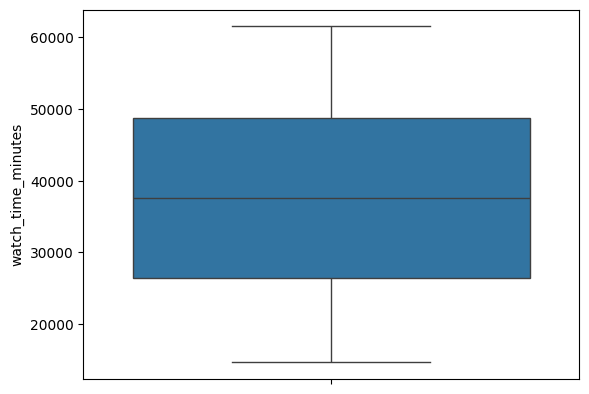

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(ad['watch_time_minutes'])
plt.show()

In [ ]:
Q1 = ad['ad_revenue_usd'].quantile(0.25)
Q3 = ad['ad_revenue_usd'].quantile(0.75)
IQR = Q3 - Q1

outliers = ad[(ad['ad_revenue_usd'] < Q1 - 1.5*IQR) |
              (ad['ad_revenue_usd'] > Q3 + 1.5*IQR)]

print(len(outliers))

0


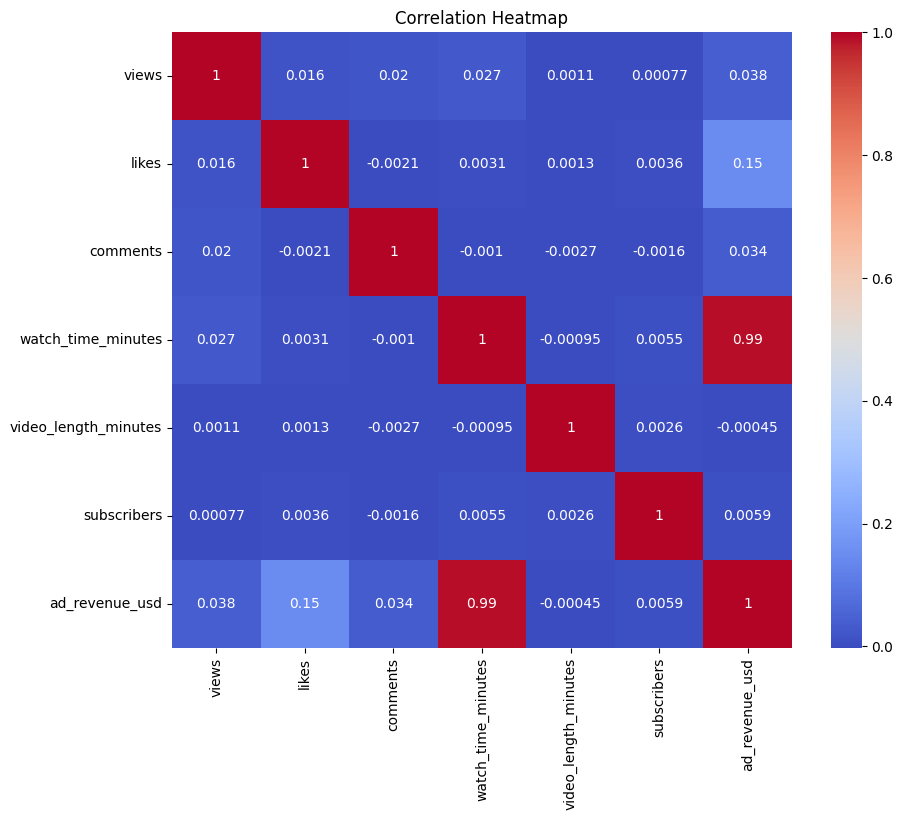

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

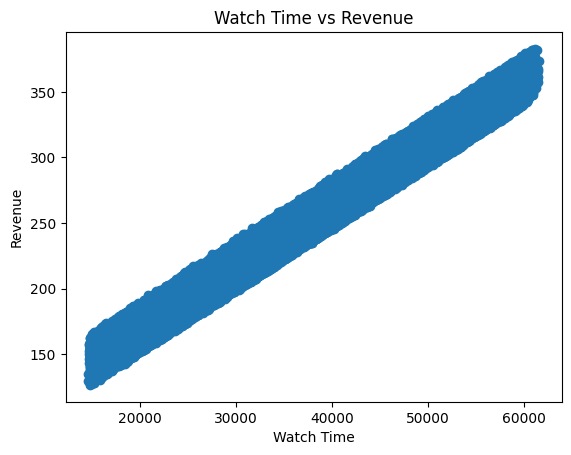

In [ ]:
plt.scatter(df['watch_time_minutes'], df['ad_revenue_usd'])
plt.xlabel("Watch Time")
plt.ylabel("Revenue")
plt.title("Watch Time vs Revenue")
plt.show()

In [ ]:
ad[['watch_time_minutes', 'ad_revenue_usd']].describe()

,watch_time_minutes,ad_revenue_usd
count,116295.000000,122400.000000
mean,37543.827721,252.727210
std,12987.724246,61.957052
min,14659.105562,126.590603
25%,26366.320569,199.902018
50%,37531.990337,252.749699
75%,48777.782090,305.597518
max,61557.670089,382.768254


In [ ]:
ad.isnull().sum()

,0
video_id,0
date,0
views,0
likes,6117
comments,6112
watch_time_minutes,6105
video_length_minutes,0
subscribers,0
category,0
device,0


In [ ]:
ad[['likes','comments','watch_time_minutes']].describe()

,likes,comments,watch_time_minutes
count,116283.000000,116288.000000,116295.000000
mean,1099.633618,274.396636,37543.827721
std,519.424089,129.741739,12987.724246
min,195.000000,48.000000,14659.105562
25%,650.000000,162.000000,26366.320569
50%,1103.000000,274.000000,37531.990337
75%,1547.000000,387.000000,48777.782090
max,2061.000000,515.000000,61557.670089


In [ ]:
ad['likes'] = ad['likes'].fillna(ad['likes'].median())
ad['comments'] = ad['comments'].fillna(ad['comments'].median())
ad['watch_time_minutes'] = ad['watch_time_minutes'].fillna(ad['watch_time_minutes'].median())

In [ ]:
ad.isnull().sum()

,0
video_id,0
date,0
views,0
likes,0
comments,0
watch_time_minutes,0
video_length_minutes,0
subscribers,0
category,0
device,0


In [ ]:
ad.duplicated().sum()

np.int64(2400)

In [ ]:
ad = ad.drop_duplicates()

In [ ]:
ad.duplicated().sum()

np.int64(0)

In [ ]:
ad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              120000 non-null  object 
 1   date                  120000 non-null  object 
 2   views                 120000 non-null  int64  
 3   likes                 120000 non-null  float64
 4   comments              120000 non-null  float64
 5   watch_time_minutes    120000 non-null  float64
 6   video_length_minutes  120000 non-null  float64
 7   subscribers           120000 non-null  int64  
 8   category              120000 non-null  object 
 9   device                120000 non-null  object 
 10  country               120000 non-null  object 
 11  ad_revenue_usd        120000 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.9+ MB


In [ ]:
ad.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [ ]:
ad.loc[:, 'engagement_rate'] = (ad['likes'] + ad['comments']) / ad['views']

In [ ]:
ad.loc[:, 'date'] = pd.to_datetime(ad['date'])

In [ ]:
ad['date'] = pd.to_datetime(ad['date'], errors='coerce')
ad.loc[:, 'year'] = ad['date'].dt.year
ad.loc[:, 'month'] = ad['date'].dt.month
ad.loc[:, 'day'] = ad['date'].dt.day

ad.loc[:, 'hour'] = ad['date'].dt.hour
ad.loc[:, 'minute'] = ad['date'].dt.minute

ad.loc[:, 'weekday'] = ad['date'].dt.weekday

In [ ]:
ad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   video_id              120000 non-null  object        
 1   date                  120000 non-null  datetime64[ns]
 2   views                 120000 non-null  int64         
 3   likes                 120000 non-null  float64       
 4   comments              120000 non-null  float64       
 5   watch_time_minutes    120000 non-null  float64       
 6   video_length_minutes  120000 non-null  float64       
 7   subscribers           120000 non-null  int64         
 8   category              120000 non-null  object        
 9   device                120000 non-null  object        
 10  country               120000 non-null  object        
 11  ad_revenue_usd        120000 non-null  float64       
 12  engagement_rate       120000 non-null  float64       
 13  year

In [ ]:
ad.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate,year,month,day,hour,minute,weekday
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.155093,2024,9,24,10,50,1
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.098632,2024,9,22,10,50,6
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.214519,2024,11,21,10,50,3
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.142814,2025,1,28,10,50,1
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.236121,2025,4,28,10,50,0


In [ ]:
ad['category'].nunique()

6

In [ ]:
ad['category'].value_counts()

,count
category,
Education,20123
Music,20065
Tech,20028
Entertainment,20025
Gaming,19974
Lifestyle,19785


In [ ]:
ad = pd.get_dummies(ad, columns=['category', 'device', 'country'], drop_first=True)

In [ ]:
ad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   video_id                120000 non-null  object        
 1   date                    120000 non-null  datetime64[ns]
 2   views                   120000 non-null  int64         
 3   likes                   120000 non-null  float64       
 4   comments                120000 non-null  float64       
 5   watch_time_minutes      120000 non-null  float64       
 6   video_length_minutes    120000 non-null  float64       
 7   subscribers             120000 non-null  int64         
 8   ad_revenue_usd          120000 non-null  float64       
 9   engagement_rate         120000 non-null  float64       
 10  year                    120000 non-null  int32         
 11  month                   120000 non-null  int32         
 12  day                     120000 non-

In [ ]:
ad = ad.drop(['video_id', 'date'], axis=1)

In [ ]:
ad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   views                   120000 non-null  int64  
 1   likes                   120000 non-null  float64
 2   comments                120000 non-null  float64
 3   watch_time_minutes      120000 non-null  float64
 4   video_length_minutes    120000 non-null  float64
 5   subscribers             120000 non-null  int64  
 6   ad_revenue_usd          120000 non-null  float64
 7   engagement_rate         120000 non-null  float64
 8   year                    120000 non-null  int32  
 9   month                   120000 non-null  int32  
 10  day                     120000 non-null  int32  
 11  hour                    120000 non-null  int32  
 12  minute                  120000 non-null  int32  
 13  weekday                 120000 non-null  int32  
 14  category_Entertainment  1

#machine learning models

In [ ]:
from sklearn.model_selection import train_test_split

X = ad.drop('ad_revenue_usd', axis=1)
y = ad['ad_revenue_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1.LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_pred_lr

array([352.8485278 , 342.28718543, 204.42532405, ..., 172.14728132,
       261.89246727, 285.49507292])

In [ ]:
print(y_test.values[:5])
print(y_pred_lr[:5])

[352.85352072 341.98378848 204.58688315 176.83567028 270.84283909]
[352.8485278  342.28718543 204.42532405 176.42830309 270.89713979]


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 181.7195800345381
MAE: 3.1187403963128126
R2 Score: 0.9525719027859166


#ridge

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred_ridge)
mae = mean_absolute_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 181.71177505095136
MAE: 3.116537695544733
R2 Score: 0.9525739398560015


#decission tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred_dt)
mae = mean_absolute_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 417.6397560130691
MAE: 5.620046158338275
R2 Score: 0.8909976627455932


#random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)


y_pred_rf = rf.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred_rf)
mae = mean_absolute_error(y_test,y_pred_rf)
r2 = r2_score(y_test,y_pred_rf  )
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 189.16412747696134
MAE: 3.5673812512109095
R2 Score: 0.9506289051202441


#xgboost

In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("XGBoost Results")
print("R2:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))

XGBoost Results
R2: 0.9521735891850104
RMSE: 13.536827868195152
MAE: 3.5199716418937133


#streamlit

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 62.2 MB/s eta 0:00:00


In [ ]:
import pickle

pickle.dump((ridge, X.columns), open('model.pkl', 'wb'))

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle

model, columns = pickle.load(open("model.pkl", "rb"))


st.set_page_config(page_title="Revenue Dashboard", layout="wide")

st.markdown("""
<style>
.main {
    background-color: #f5f7fa;
}
.block-container {
    padding-top: 2rem;
}
h1 {
    color: #1f77b4;
}
.stButton>button {
    background-color: #1f77b4;
    color: white;
    border-radius: 10px;
    height: 3em;
    width: 100%;
}
</style>
""", unsafe_allow_html=True)

# Title
st.title(" YouTube Revenue Dashboard")
st.markdown("### Predict revenue based on video performance")

# Cards layout
col1, col2, col3 = st.columns(3)

with col1:
    views = st.number_input("👀 Views", value=10000)
    likes = st.number_input(" Likes", value=1000)

with col2:
    comments = st.number_input(" Comments", value=200)
    watch_time = st.number_input("Watch Time (min)", value=30000)

with col3:
    subscribers = st.number_input(" Subscribers", value=500000)
    video_length = st.number_input(" Video Length", value=10)

col4, col5, col6 = st.columns(3)

with col4:
    category = st.selectbox(" Category",
        ["Education", "Music", "Tech", "Entertainment", "Gaming", "Lifestyle"])

with col5:
    device = st.selectbox(" Device", ["Mobile", "TV", "Tablet"])

with col6:
    country = st.selectbox(" Country", ["IN", "US", "UK", "CA", "DE"])

engagement_rate = (likes + comments) / views if views > 0 else 0

st.divider()

if st.button(" Predict Revenue"):

    input_df = pd.DataFrame(columns=columns)
    input_df.loc[0] = 0

    input_df.at[0, 'views'] = views
    input_df.at[0, 'likes'] = likes
    input_df.at[0, 'comments'] = comments
    input_df.at[0, 'watch_time_minutes'] = watch_time
    input_df.at[0, 'video_length_minutes'] = video_length
    input_df.at[0, 'subscribers'] = subscribers
    input_df.at[0, 'engagement_rate'] = engagement_rate

    if f'category_{category}' in input_df.columns:
        input_df.at[0, f'category_{category}'] = 1

    if f'device_{device}' in input_df.columns:
        input_df.at[0, f'device_{device}'] = 1

    if f'country_{country}' in input_df.columns:
        input_df.at[0, f'country_{country}'] = 1

    prediction = model.predict(input_df)[0]

    # Output section
    st.subheader(" Revenue Prediction")

    st.metric("Estimated Revenue", f"${prediction:.2f}")



    if prediction < 20000:
        st.error("Low revenue ")
    elif prediction < 30000:
        st.warning("Average performance")
    else:
        st.success("High revenue  Great performance!")


Overwriting app.py


In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
from pyngrok import ngrok


ngrok.set_auth_token("3D1gKUjT4FxghAQMeM2toSrvny8_2E17xUa9cnKs2bSy8Uktp")

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://grouped-unnerving-handshake.ngrok-free.dev" -> "http://localhost:8501"
